# Weight Pruning — Paper Analysis

Final figures for the weight-pruning paper, drawing on four sweep families that all share the
same per-task parameter budget of ~19056 weights at `n_tasks=4`:

| # | Source | Description |
|---|---|---|
| 01 | `paper-weight-pruning-scaling-best` | Stationary best (block-sparse + dense scaling), 30 seeds |
| 02 | `paper-weight-pruning-scaling-best` | Non-stationary best (all 4 methods), 30 seeds |
| 02-sweep | `paper-weight-pruning-scaling-sweep` | Non-stationary LR sweep (used only for size-matching defaults) |
| 03 | `paper-weight-pruning-scaling-sweep` | Non-stationary, scaling `n_tasks ∈ {2,4,8,16,32}`, 5 seeds |
| 04 | `paper-weight-pruning-scaling-sweep` | Non-stationary, scaling `permute_period ∈ {200,...,6400}`, 5 seeds |

Plots 1-4 use a 4-column layout (large text), 5-7 use a 3-column layout, 8-9 use a 2-column
layout. Loss is reported per task (`loss / n_tasks`). Confidence intervals are only shown on
learning curves with 30 seeds.

In [1]:
# Run once to fetch from MLflow. Comment out after first run.
# import os
# os.environ['MLFLOW_TRACKING_URI'] = 'postgresql:///mlflow?host=/var/run/postgresql&port=5433'
# os.environ['OPTUNA_TRACKING_URI'] = 'postgresql:///optuna?host=/var/run/postgresql&port=5433'
# from phd.research_utils.scripts.mlflow_download import download_experiment
# download_experiment('paper-weight-pruning-scaling-sweep', output_dir='data', include_seed_runs=True)
# download_experiment('paper-weight-pruning-scaling-best',  output_dir='data', include_seed_runs=True)

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from phd.research_utils.analysis.analysis_utils import *
from phd.research_utils.analysis.plotting import plot_learning_curves, plot_param_sensitivity

%matplotlib inline

# Method palette shared across panels (color-blind-safe variant inside).
METHOD_ORDER = ['Dense', 'Block-Sparse', 'Random-Sparse', 'Structure Search']
PALETTE = get_color_palette(classes=METHOD_ORDER)

# Per-section column-layout style helpers. The repo only ships '4-row' and '2-row'; we add a
# medium tier for the 3-column sections.
def apply_style(cols):
    set_matplotlib_style('default')  # reset first
    if cols == 4:
        plt.rcParams.update({
            'figure.figsize': (5, 4),
            'axes.labelsize': 23, 'axes.titlesize': 25, 'axes.titlepad': 21,
            'xtick.labelsize': 18, 'ytick.labelsize': 18,
            'legend.fontsize': 17, 'legend.title_fontsize': 18,
            'lines.linewidth': 2.7,
        })
    elif cols == 3:
        plt.rcParams.update({
            'figure.figsize': (6, 4.3),
            'axes.labelsize': 21, 'axes.titlesize': 23, 'axes.titlepad': 19,
            'xtick.labelsize': 17, 'ytick.labelsize': 17,
            'legend.fontsize': 16, 'legend.title_fontsize': 17,
            'lines.linewidth': 2.9,
        })
    elif cols == 2:
        plt.rcParams.update({
            'figure.figsize': (7, 4.25),
            'axes.labelsize': 20, 'axes.titlesize': 22, 'axes.titlepad': 18,
            'xtick.labelsize': 16, 'ytick.labelsize': 16,
            'legend.fontsize': 15, 'legend.title_fontsize': 16,
            'lines.linewidth': 2.3,
        })
    else:
        raise ValueError(f'Unknown cols={cols}')


def save_fig(name):
    """Save current figure to both pdf/ and png/ subdirs of figures/.

    Wraps save_fig_versions but also toggles figure-level legends. The
    upstream helper only handles ax.get_legend(); plot_learning_curves and
    our custom helpers use fig.legend(...), so without this the _nl variants
    would still show the legend.
    """
    fig = plt.gcf()
    fig_legends = [c for c in fig.legends]
    for sub in ['pdf', 'png']:
        # No-legend variant: hide everything.
        for lg in fig_legends:
            lg.set_visible(False)
        ax_lg = plt.gca().get_legend()
        if ax_lg is not None:
            ax_lg.set_visible(False)
        path = f'figures/{sub}/{name}_nl.{sub}'
        plt.savefig(path, bbox_inches='tight', dpi=400)
        # With-legend variant: restore.
        for lg in fig_legends:
            lg.set_visible(True)
        if ax_lg is not None:
            ax_lg.set_visible(True)
        path = f'figures/{sub}/{name}.{sub}'
        plt.savefig(path, bbox_inches='tight', dpi=400)

## Resolve child sweep names

Per-seed child runs only carry a `mlflow.parentRunId` tag; their `sweep_name` falls back to
`'default'` in the downloaded CSV. Look up each child's parent and copy its `sweep_name` over
so we can bucket per-seed rows correctly.

In [3]:
def resolve_default_sweep_names(params_path, experiment_name, cache_path):
    df = pd.read_csv(params_path, index_col=0)
    if (df['sweep_name'] == 'default').sum() == 0:
        return
    cache_stale = (
        not os.path.exists(cache_path)
        or os.path.getmtime(cache_path) < os.path.getmtime(params_path)
    )
    if cache_stale:
        import mlflow
        from mlflow.tracking import MlflowClient
        mlflow.set_tracking_uri(os.environ.get('MLFLOW_TRACKING_URI', 'sqlite:///mlruns.db'))
        client = MlflowClient()
        exp = client.get_experiment_by_name(experiment_name)
        all_runs = client.search_runs(experiment_ids=[exp.experiment_id], max_results=50000)
        sweep_by = {r.info.run_id: r.data.tags.get('sweep_name', 'default') for r in all_runs}
        rows = []
        for r in all_runs:
            pid = r.data.tags.get('mlflow.parentRunId')
            if pid:
                rows.append({'run_id': r.info.run_id, 'parent_sweep': sweep_by.get(pid, 'default')})
        pd.DataFrame(rows).to_csv(cache_path, index=False)

    map_df = pd.read_csv(cache_path)
    map_dict = dict(zip(map_df['run_id'], map_df['parent_sweep']))
    is_default = df['sweep_name'] == 'default'
    df.loc[is_default, 'sweep_name'] = df.loc[is_default, 'run_id'].map(map_dict).fillna('default')
    df.to_csv(params_path)
    print(f'Resolved {is_default.sum()} child rows in {params_path}')


resolve_default_sweep_names(
    'data/paper_weight_pruning_scaling_sweep_params.csv',
    'paper-weight-pruning-scaling-sweep',
    'data/scaling_sweep_parent_map.csv',
)
resolve_default_sweep_names(
    'data/paper_weight_pruning_scaling_best_params.csv',
    'paper-weight-pruning-scaling-best',
    'data/scaling_best_parent_map.csv',
)

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Resolved 1620 child rows in data/paper_weight_pruning_scaling_best_params.csv


## Load data and helpers

In [4]:
sweep_cfg, sweep_run = load_experiment_data(
    'data/paper_weight_pruning_scaling_sweep_params.csv',
    'data/paper_weight_pruning_scaling_sweep_metrics.csv',
)
best_cfg, best_run = load_experiment_data(
    'data/paper_weight_pruning_scaling_best_params.csv',
    'data/paper_weight_pruning_scaling_best_metrics.csv',
)


def drop_summary_rows(run_dfs):
    """Strip the single end-of-training summary row (loss is NaN, asymptotic_loss is set)."""
    for k, rdf in run_dfs.items():
        mask = rdf['loss'].isna() & rdf['asymptotic_loss'].notna()
        run_dfs[k] = rdf[~mask].copy()


drop_summary_rows(sweep_run)
drop_summary_rows(best_run)
print('Sweep buckets:', sorted(sweep_cfg.keys()))
print()
print('Best buckets :', sorted(best_cfg.keys()))

Sweep buckets: ['01_block_sparse_4task_lr', '01_dense_4task_scaling_lr', '02_block_sparse_4task_nonstationary_lr', '02_dense_4task_nonstationary_scaling_lr', '02_dense_scaling_4task_nonstationary_lr', '02_random_sparse_4task_nonstationary_lr', '02_structure_search_4task_nonstationary_lr', '02b_block_sparse_4task_nonstationary_lr', '02b_dense_4task_nonstationary_scaling_lr', '03_block_sparse_n_tasks_lr', '03_dense_n_tasks_lr', '03_random_sparse_n_tasks_lr', '03_random_sparse_n_tasks_sparsity_high_lr', '03_random_sparse_n_tasks_sparsity_lr', '03_structure_search_n_tasks_lr', '04_block_sparse_permute_period_lr', '04_dense_permute_period_lr', '04_random_sparse_permute_period_lr', '04_structure_search_permute_period_lr']

Best buckets : ['01_block_sparse_4task_best', '01_dense_scaling_4task_best', '02_block_sparse_4task_nonstationary_best', '02_block_sparse_4task_nonstationary_best_high_freq', '02_dense_scaling_4task_nonstationary_best', '02_dense_scaling_4task_nonstationary_best_high_freq'

In [5]:
def add_method_col(cfg):
    cfg = cfg.copy()
    ss = cfg.get('structure_search.enabled', pd.Series('False', index=cfg.index))
    ss = ss.astype(str).str.lower().eq('true')
    init = cfg.get('model.init_strategy', pd.Series('', index=cfg.index)).astype(str)
    method = pd.Series(index=cfg.index, dtype=object)
    method[ss] = 'Structure Search'
    method[~ss & (init == 'dense')] = 'Dense'
    method[~ss & (init == 'block_sparse')] = 'Block-Sparse'
    method[~ss & (init == 'random_sparse')] = 'Random-Sparse'
    cfg['Method'] = method
    return cfg


def gather(cfg_dfs, run_dfs, sweep_pattern, *, per_seed):
    """Pull rows from sweep buckets matching ``sweep_pattern``.

    per_seed=True  -> keep child rows (one per seed; for 30-seed best runs with CIs).
    per_seed=False -> keep parent rows only (each parent's metric history is the seed mean).
    """
    keys = [k for k in cfg_dfs if sweep_pattern(k)]
    if not keys:
        return pd.DataFrame(), pd.DataFrame()
    cfg = pd.concat([cfg_dfs[k] for k in keys], ignore_index=True)
    run = pd.concat([run_dfs[k] for k in keys], ignore_index=True)
    if 'child_seed' in cfg.columns:
        if per_seed:
            cfg = cfg[cfg['child_seed'].notna()].copy()
        else:
            cfg = cfg[cfg['child_seed'].isna()].copy()
        run = run[run['run_id'].isin(cfg['run_id'])].copy()
    cfg = add_method_col(cfg)
    cfg = cfg[cfg['Method'].notna()].copy()
    run = run[run['run_id'].isin(cfg['run_id'])].copy()
    for col in ('optimizer.learning_rate', 'task.n_tasks', 'task.permute_period',
                'model.initial_hidden_units'):
        if col in cfg.columns:
            cfg[col] = pd.to_numeric(cfg[col], errors='coerce')
    nt_map = dict(zip(cfg['run_id'], cfg.get('task.n_tasks', pd.Series(1, index=cfg.index))))
    run['loss_per_task'] = run['loss'] / run['run_id'].map(nt_map).fillna(1.0)
    return cfg, run


def asymptotic_per_run(run, metric_col, frac=0.05):
    """Mean of metric_col over the final `frac` of each run's steps. NaN is propagated:
    if any logged value in the window is NaN, the run's asymptotic is NaN."""
    max_step = run.groupby('run_id')['step'].max()
    thr = (max_step * (1.0 - frac)).rename('_thr')
    rdf = run.merge(thr, left_on='run_id', right_index=True)
    last = rdf[rdf['step'] >= rdf['_thr']]
    # skipna=False so a single NaN poisons the whole run's asymptotic, which then
    # propagates through downstream groupbys; idxmin/idxmax will simply skip those
    # NaN cells when picking the best LR (never selecting them).
    return last.groupby('run_id')[metric_col].apply(lambda s: s.mean(skipna=False)).rename('_metric')


def filter_to_best(cfg, run, group_cols, metric_col, direction='min'):
    """Keep the LR with best mean asymptotic metric within each (group_cols) cell."""
    per_run = asymptotic_per_run(run, metric_col).reset_index()
    merged = cfg.merge(per_run, on='run_id')
    # skipna=False inside cell aggregation: if any seed/replicate is NaN, the cell is NaN.
    agg = (
        merged.groupby(group_cols + ['optimizer.learning_rate'], dropna=False)['_metric']
        .apply(lambda s: s.mean(skipna=False))
        .reset_index()
    )
    # idxmin/idxmax skip NaN entries -> NaN cells are never selected.
    idx = agg.groupby(group_cols, dropna=False)['_metric'].idxmin() if direction == 'min' \
        else agg.groupby(group_cols, dropna=False)['_metric'].idxmax()
    best = agg.loc[idx]
    keep = set(map(tuple, best[group_cols + ['optimizer.learning_rate']].values))
    keys = list(map(tuple, cfg[group_cols + ['optimizer.learning_rate']].values))
    mask = pd.Series([k in keep for k in keys], index=cfg.index)
    return cfg[mask].copy(), run[run['run_id'].isin(cfg.loc[mask, 'run_id'])].copy()

---
## 1. Stationary: Block-Sparse vs Dense (Matched Size)

Both methods use ~19056 weights: block-sparse with 24 units (one per task × 6 units), dense
with 6 fully-connected units. 30 seeds, 95% CI.

In [6]:
apply_style(2)

s01_best_cfg, s01_best_run = gather(
    best_cfg, best_run,
    sweep_pattern=lambda k: k.startswith('01_') and k.endswith('_best'),
    per_seed=True,
)
# Match block-sparse 24-unit budget with dense 6-unit budget.
match_mask = (
    ((s01_best_cfg['Method'] == 'Block-Sparse') & (s01_best_cfg['model.initial_hidden_units'] == 24))
    | ((s01_best_cfg['Method'] == 'Dense') & (s01_best_cfg['model.initial_hidden_units'] == 6))
)
p1_cfg = s01_best_cfg[match_mask].copy()
p1_run = s01_best_run[s01_best_run['run_id'].isin(p1_cfg['run_id'])].copy()
print(f'Plot 1: {len(p1_cfg)} per-seed rows '
      f'(Block-Sparse: {(p1_cfg["Method"] == "Block-Sparse").sum()}, '
      f'Dense: {(p1_cfg["Method"] == "Dense").sum()})')

Plot 1: 60 per-seed rows (Block-Sparse: 30, Dense: 30)


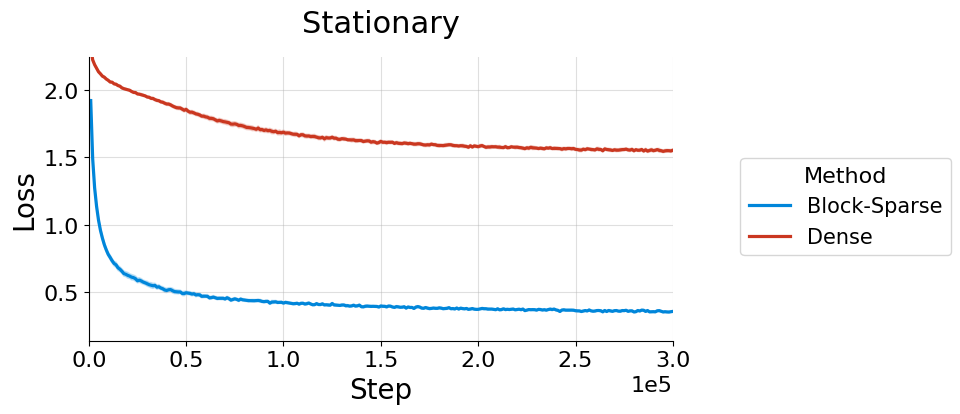

In [7]:
plot_learning_curves(
    run_df=p1_run, config_df=p1_cfg,
    n_bins=-1, figsize=(7, 4.25),
    y_col='loss_per_task', y_label='Loss',
    hue_col='Method', legend_title='Method', palette=PALETTE,
    show_ci=True,
)
plt.title('Stationary')
plt.tight_layout()
plt.xlim(0, 300_000)
plt.xlabel('Step'); save_fig('p1_stationary_bs_vs_dense_matched_loss')
plt.show()

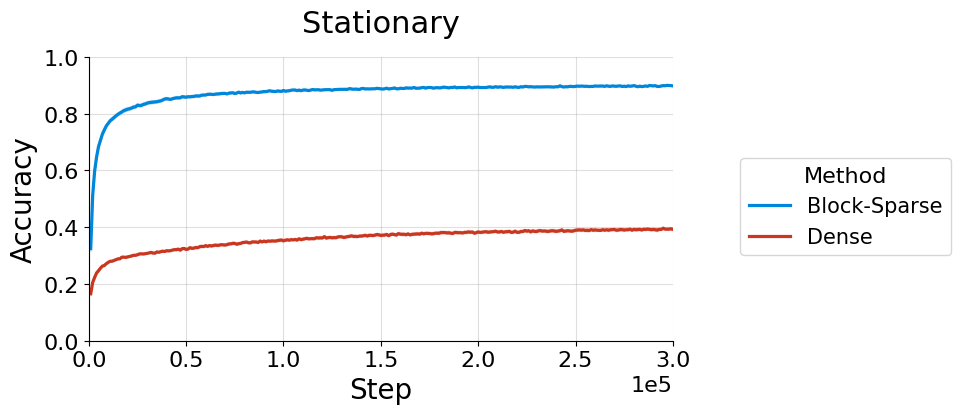

In [8]:
plot_learning_curves(
    run_df=p1_run, config_df=p1_cfg,
    n_bins=-1, figsize=(7, 4.25),
    y_col='accuracy', y_label='Accuracy', ylim=(0.0, 1.0),
    hue_col='Method', legend_title='Method', palette=PALETTE,
    show_ci=True,
)
plt.title('Stationary')
plt.tight_layout()
plt.xlim(0, 300_000)
plt.xlabel('Step'); save_fig('p1_stationary_bs_vs_dense_matched_acc')
plt.show()

---
## 2. Non-Stationary: Block-Sparse vs Dense (Matched Size)

Same matched budgets, but with `permute_period = 800`.

In [9]:
apply_style(2)

s02_best_cfg, s02_best_run = gather(
    best_cfg, best_run,
    sweep_pattern=lambda k: k.startswith('02_') and k.endswith('_best'),
    per_seed=True,
)
match_mask = (
    ((s02_best_cfg['Method'] == 'Block-Sparse') & (s02_best_cfg['model.initial_hidden_units'] == 24))
    | ((s02_best_cfg['Method'] == 'Dense') & (s02_best_cfg['model.initial_hidden_units'] == 6))
)
p2_cfg = s02_best_cfg[match_mask].copy()
p2_run = s02_best_run[s02_best_run['run_id'].isin(p2_cfg['run_id'])].copy()
print(f'Plot 2: {len(p2_cfg)} per-seed rows '
      f'(Block-Sparse: {(p2_cfg["Method"] == "Block-Sparse").sum()}, '
      f'Dense: {(p2_cfg["Method"] == "Dense").sum()})')

Plot 2: 60 per-seed rows (Block-Sparse: 30, Dense: 30)


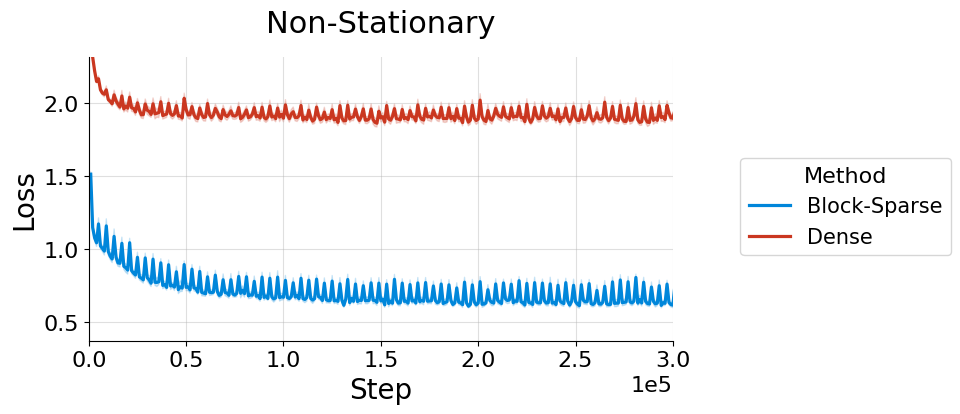

In [10]:
plot_learning_curves(
    run_df=p2_run, config_df=p2_cfg,
    n_bins=-1, figsize=(7, 4.25),
    y_col='loss_per_task', y_label='Loss',
    hue_col='Method', legend_title='Method', palette=PALETTE,
    show_ci=True,
)
plt.title('Non-Stationary')
plt.tight_layout()
plt.xlim(0, 300_000)
plt.xlabel('Step'); save_fig('p2_nonstationary_bs_vs_dense_matched_loss')
plt.show()

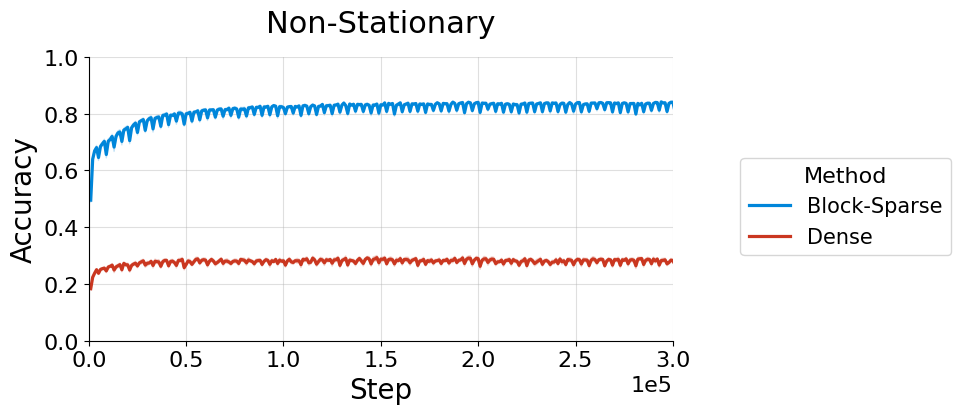

In [11]:
plot_learning_curves(
    run_df=p2_run, config_df=p2_cfg,
    n_bins=-1, figsize=(7, 4.25),
    y_col='accuracy', y_label='Accuracy', ylim=(0.0, 1.0),
    hue_col='Method', legend_title='Method', palette=PALETTE,
    show_ci=True,
)
plt.title('Non-Stationary')
plt.tight_layout()
plt.xlim(0, 300_000)
plt.xlabel('Step'); save_fig('p2_nonstationary_bs_vs_dense_matched_acc')
plt.show()

---
## 2b. High-Frequency Logging: Block-Sparse vs Dense vs Random-Sparse (Matched Size)

Same setup as plot 2 but trained with `train.log_freq=100` (vs 1000) so the per-permutation
saw-tooth pattern is resolved. Random-sparse at 96 units is included since the high-freq
sweep set also covers it. 30 seeds, 95% CI.

In [12]:
apply_style(2)

s02_hf_cfg, s02_hf_run = gather(
    best_cfg, best_run,
    sweep_pattern=lambda k: k.startswith('02_') and k.endswith('_best_high_freq'),
    per_seed=True,
)
match_mask = (
    ((s02_hf_cfg['Method'] == 'Block-Sparse') & (s02_hf_cfg['model.initial_hidden_units'] == 24))
    | ((s02_hf_cfg['Method'] == 'Dense') & (s02_hf_cfg['model.initial_hidden_units'] == 6))
    | (s02_hf_cfg['Method'] == 'Random-Sparse')
)
p2b_cfg = s02_hf_cfg[match_mask].copy()
p2b_run = s02_hf_run[s02_hf_run['run_id'].isin(p2b_cfg['run_id'])].copy()
print('Plot 2b per-seed counts by method:')
print(p2b_cfg.groupby('Method').size())

Plot 2b per-seed counts by method:
Method
Block-Sparse     30
Dense            30
Random-Sparse    30
dtype: int64


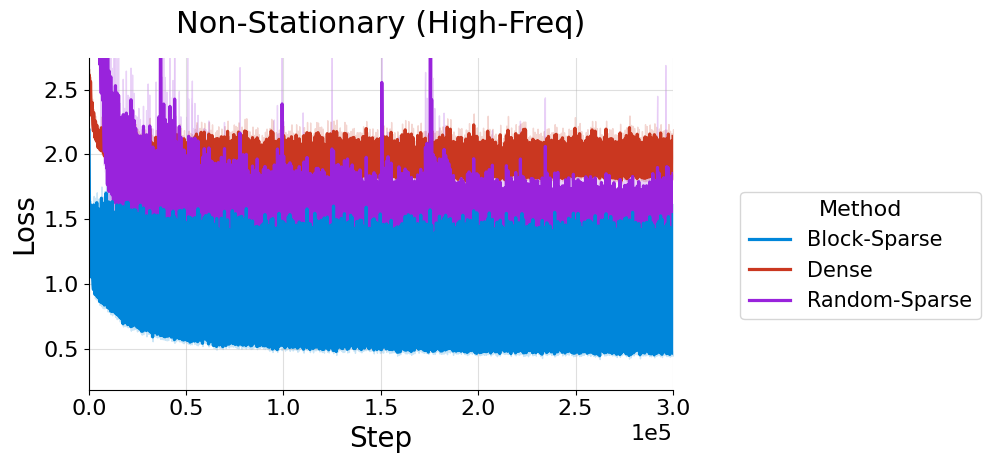

In [13]:
plot_learning_curves(
    run_df=p2b_run, config_df=p2b_cfg,
    n_bins=-1, figsize=(7, 4.25),
    y_col='loss_per_task', y_label='Loss',
    hue_col='Method', legend_title='Method', palette=PALETTE,
    show_ci=True,
)
plt.title('Non-Stationary (High-Freq)')
plt.xlabel('Step')
plt.xlim(0, 300_000)
save_fig('p2b_nonstationary_matched_high_freq_loss')
plt.show()

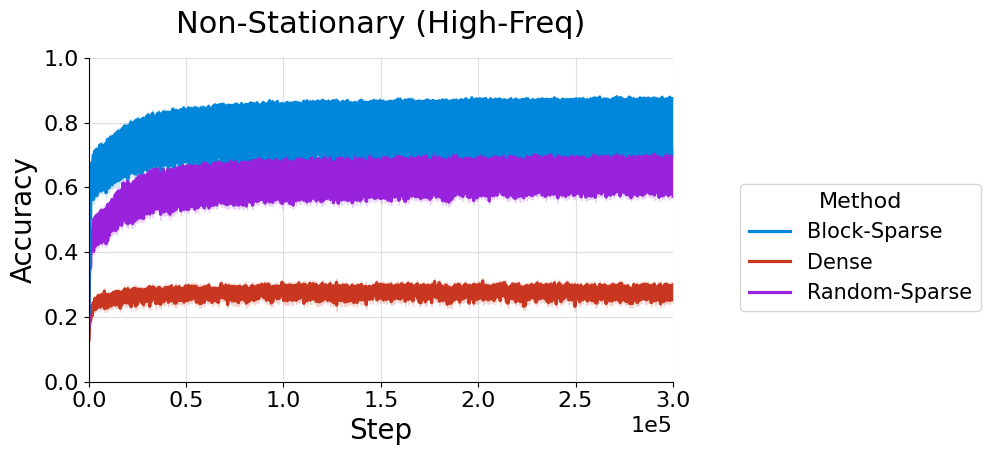

In [14]:
plot_learning_curves(
    run_df=p2b_run, config_df=p2b_cfg,
    n_bins=-1, figsize=(7, 4.25),
    y_col='accuracy', y_label='Accuracy', ylim=(0.0, 1.0),
    hue_col='Method', legend_title='Method', palette=PALETTE,
    show_ci=True,
)
plt.title('Non-Stationary (High-Freq)')
plt.xlabel('Step')
plt.xlim(0, 300_000)
save_fig('p2b_nonstationary_matched_high_freq_acc')
plt.show()

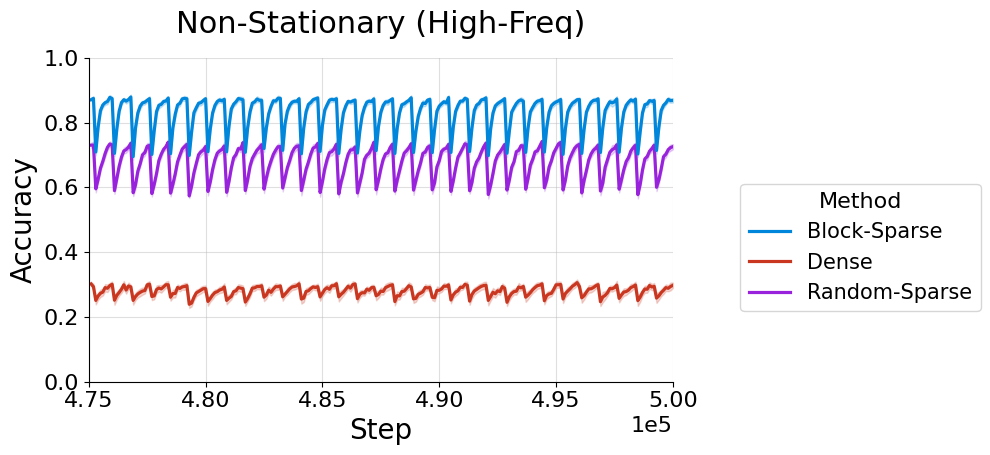

In [15]:
x_start = 475_000
short_p2b_run = p2b_run[(p2b_run['step'] > x_start)].copy()
plot_learning_curves(
    run_df=short_p2b_run, config_df=p2b_cfg,
    n_bins=-1, figsize=(7, 4.25),
    y_col='accuracy', y_label='Accuracy', ylim=(0.0, 1.0),
    hue_col='Method', legend_title='Method', palette=PALETTE,
    show_ci=True,
)
plt.title('Non-Stationary (High-Freq)')
plt.xlabel('Step')
plt.xlim(x_start)
save_fig('p2b_nonstationary_matched_high_freq_acc')
plt.show()

---
## 3. Stationary: Dense Scaling vs Block-Sparse Reference

Dense at all 7 budgets (6, 12, 24, 48, 96, 192, 384 units), with a horizontal line marking
block-sparse asymptotic performance at the 2× budget (24 units).

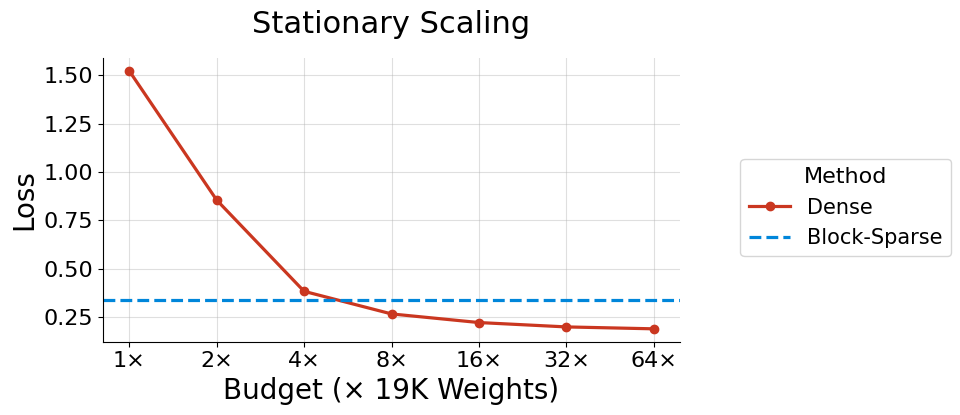

In [16]:
apply_style(2)

# Use parent rows: each parent's asymptotic metric is already the seed-averaged value.
s01_best_cfg_par, s01_best_run_par = gather(
    best_cfg, best_run,
    sweep_pattern=lambda k: k.startswith('01_') and k.endswith('_best'),
    per_seed=False,
)
de_p_cfg = s01_best_cfg_par[s01_best_cfg_par['Method'] == 'Dense'].copy()
de_p_run = s01_best_run_par[s01_best_run_par['run_id'].isin(de_p_cfg['run_id'])].copy()
bs_p_cfg = s01_best_cfg_par[s01_best_cfg_par['Method'] == 'Block-Sparse'].copy()
bs_p_run = s01_best_run_par[s01_best_run_par['run_id'].isin(bs_p_cfg['run_id'])].copy()


def per_size_asymptotic(cfg, run, metric_col):
    per_run = asymptotic_per_run(run, metric_col).reset_index()
    df = cfg.merge(per_run, on='run_id')
    return df.groupby('model.initial_hidden_units', dropna=False)['_metric'].mean().reset_index()


def block_sparse_asymptote(cfg, run, metric_col):
    per_run = asymptotic_per_run(run, metric_col).reset_index()
    df = cfg.merge(per_run, on='run_id')
    return df['_metric'].mean()


SIZE_TO_MULT = {6: '1×', 12: '2×', 24: '4×', 48: '8×', 96: '16×', 192: '32×', 384: '64×'}


def scaling_plot(de_cfg, de_run, bs_cfg, bs_run, metric_col, y_label, title, savename, ylim=None):
    de_asym = per_size_asymptotic(de_cfg, de_run, metric_col).sort_values('model.initial_hidden_units')
    bs_y = block_sparse_asymptote(bs_cfg, bs_run, metric_col)
    color = PALETTE.get('Dense', 'C0')
    bs_color = PALETTE.get('Block-Sparse', 'C1')
    fig, ax = plt.subplots(figsize=(7, 4.25))
    ax.plot(de_asym['model.initial_hidden_units'], de_asym['_metric'],
            marker='o', color=color, label='Dense')
    ax.axhline(bs_y, color=bs_color, linestyle='--', label='Block-Sparse')
    ax.set_xscale('log', base=2)
    ax.set_xticks(de_asym['model.initial_hidden_units'].tolist())
    ax.set_xticklabels([SIZE_TO_MULT.get(int(x), str(int(x))) for x in de_asym['model.initial_hidden_units']])
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xlabel('Budget (× 19K Weights)')
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(True, alpha=0.4)
    # Match plot_learning_curves' fig.legend placement so bbox_inches='tight'
    # crops to the same outer width.
    ax.get_legend().remove() if ax.get_legend() else None
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, title='Method', frameon=True,
               bbox_to_anchor=(1.05, 0.5), loc='center left')
    plt.tight_layout()
    save_fig(savename)
    plt.show()


scaling_plot(de_p_cfg, de_p_run, bs_p_cfg, bs_p_run, 'loss_per_task',
             y_label='Loss', title='Stationary Scaling',
             savename='p3_stationary_scaling_loss')

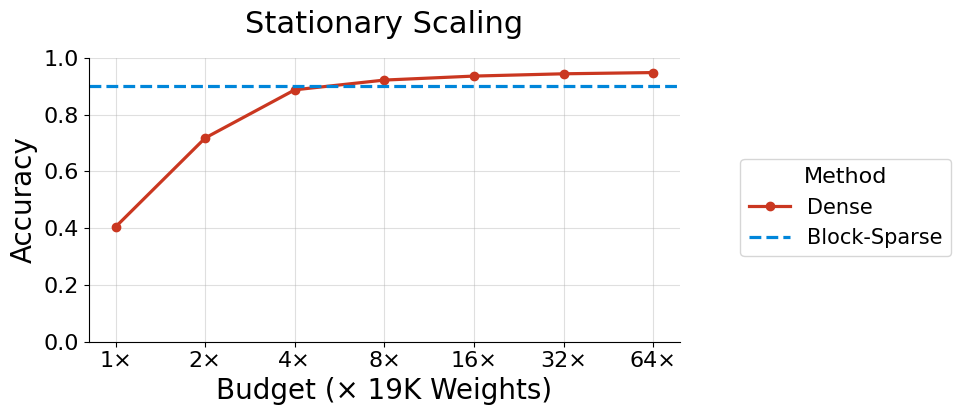

In [17]:
apply_style(2)
scaling_plot(de_p_cfg, de_p_run, bs_p_cfg, bs_p_run, 'accuracy',
             y_label='Accuracy', title='Stationary Scaling',
             savename='p3_stationary_scaling_acc', ylim=(0.0, 1.0))

---
## 4. Non-Stationary: Dense Scaling vs Block-Sparse Reference

Same as plot 3 but with `permute_period = 800`.

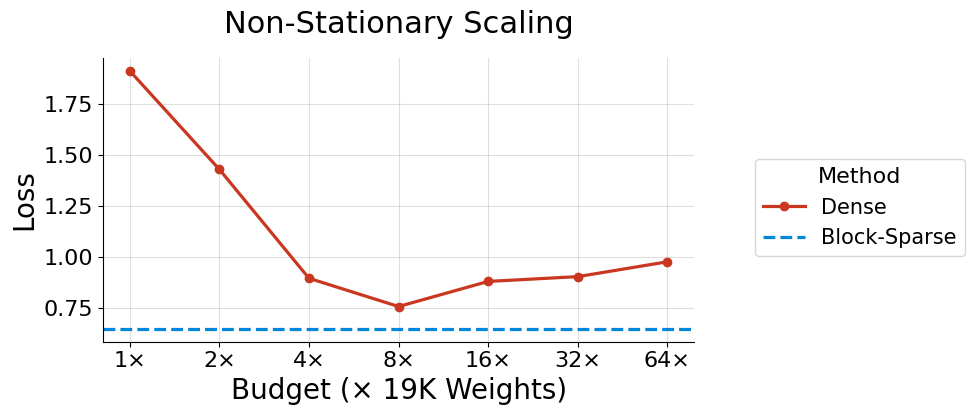

In [18]:
apply_style(2)

s02_best_cfg_par, s02_best_run_par = gather(
    best_cfg, best_run,
    sweep_pattern=lambda k: k.startswith('02_') and k.endswith('_best'),
    per_seed=False,
)
de2_p_cfg = s02_best_cfg_par[s02_best_cfg_par['Method'] == 'Dense'].copy()
de2_p_run = s02_best_run_par[s02_best_run_par['run_id'].isin(de2_p_cfg['run_id'])].copy()
bs2_p_cfg = s02_best_cfg_par[s02_best_cfg_par['Method'] == 'Block-Sparse'].copy()
bs2_p_run = s02_best_run_par[s02_best_run_par['run_id'].isin(bs2_p_cfg['run_id'])].copy()

scaling_plot(de2_p_cfg, de2_p_run, bs2_p_cfg, bs2_p_run, 'loss_per_task',
             y_label='Loss', title='Non-Stationary Scaling',
             savename='p4_nonstationary_scaling_loss')

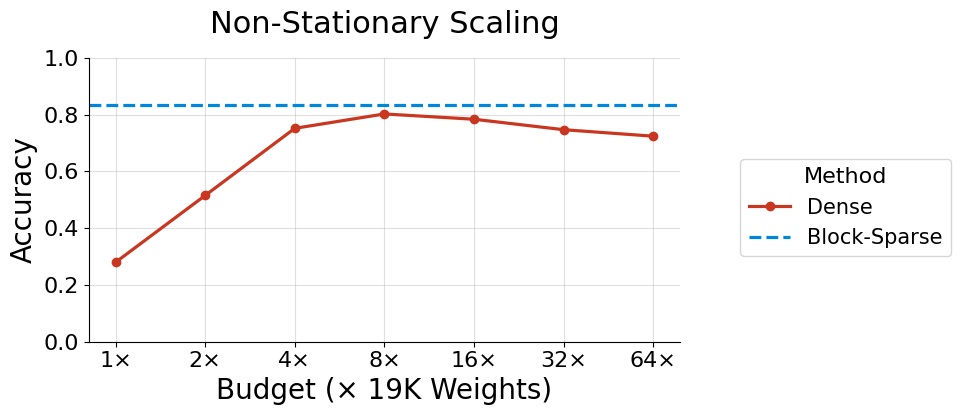

In [19]:
apply_style(2)
scaling_plot(de2_p_cfg, de2_p_run, bs2_p_cfg, bs2_p_run, 'accuracy',
             y_label='Accuracy', title='Non-Stationary Scaling',
             savename='p4_nonstationary_scaling_acc', ylim=(0.0, 1.0))

---
## 4b. Non-Stationary: All 4 Methods Size Scaling

Asymptotic accuracy (mean of the final 10% of training steps, averaged across the 30 seeds)
vs total parameter budget for all four methods on a common log-2 x-axis. Each (method,
budget) point uses the best LR for that cell, baked into the per-method `base_*_best.yaml`.

In [ ]:
apply_style(2)

s02b_cfg, s02b_run = gather(
    best_cfg, best_run,
    sweep_pattern=lambda k: k.startswith('02b_') and k.endswith('_best'),
    per_seed=False,
)


def budget_multiplier(row):
    method = row['Method']
    units = row.get('model.initial_hidden_units')
    budget = row.get('structure_search.connection_budget')
    base_units = {'Block-Sparse': 24, 'Dense': 6, 'Random-Sparse': 384}.get(method)
    if base_units is not None and pd.notna(units):
        return float(units) / base_units
    if method == 'Structure Search' and pd.notna(budget):
        return float(budget) / 19056
    return None


s02b_cfg['budget_mult'] = s02b_cfg.apply(budget_multiplier, axis=1)
print('02b best counts by method:')
print(s02b_cfg.groupby('Method').size())

02b best counts by method:
Method
Block-Sparse        7
Dense               7
Random-Sparse       7
Structure Search    6
dtype: int64


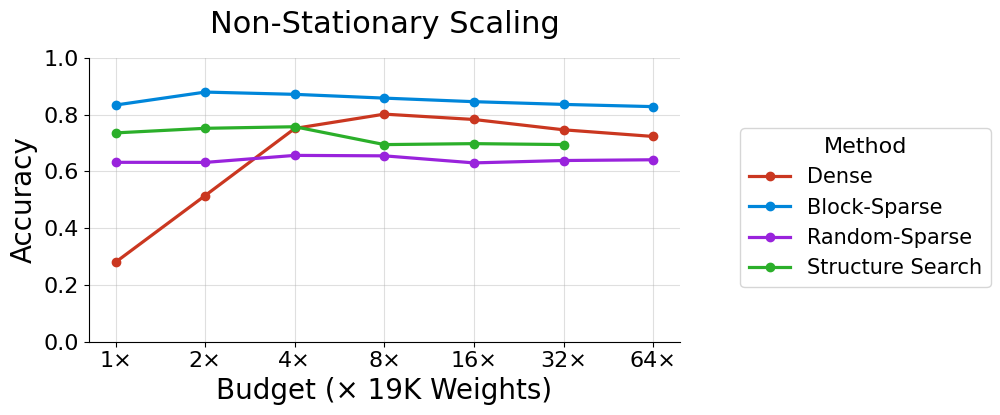

In [21]:
apply_style(2)

# Asymptotic = mean of final 10% of each parent run's history (seed-averaged
# already, so the parent value IS the 30-seed mean). NaN propagates.
asym = asymptotic_per_run(s02b_run, 'accuracy', frac=0.10).reset_index()
merged = s02b_cfg.merge(asym, on='run_id')
agg = (
    merged.groupby(['Method', 'budget_mult'], dropna=False)['_metric']
    .apply(lambda s: s.mean(skipna=False))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 4.25))
for method in METHOD_ORDER:
    sub = agg[agg['Method'] == method].dropna(subset=['_metric']).sort_values('budget_mult')
    if sub.empty:
        continue
    ax.plot(sub['budget_mult'], sub['_metric'], marker='o',
            color=PALETTE[method], label=method)

multipliers = [1, 2, 4, 8, 16, 32, 64]
ax.set_xscale('log', base=2)
ax.set_xticks(multipliers)
ax.set_xticklabels([f'{m}×' for m in multipliers])
ax.set_ylim(0.0, 1.0)
ax.set_xlabel('Budget (× 19K Weights)')
ax.set_ylabel('Accuracy')
ax.set_title('Non-Stationary Scaling')
ax.grid(True, alpha=0.4)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title='Method', frameon=True,
           bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.tight_layout()
save_fig('p4b_nonstationary_all_methods_scaling_acc')
plt.show()

---
## 5. Non-Stationary: All 4 Methods (Matched Size)

Each method at the ~19056-weight setting (block-sparse 24 units, dense 6 units, random-sparse
96 units, structure-search budget 19056). 30 seeds, 95% CI.

In [22]:
apply_style(2)

match_mask_5 = (
    ((s02_best_cfg['Method'] == 'Block-Sparse') & (s02_best_cfg['model.initial_hidden_units'] == 24))
    | ((s02_best_cfg['Method'] == 'Dense') & (s02_best_cfg['model.initial_hidden_units'] == 6))
    | (s02_best_cfg['Method'] == 'Random-Sparse')
    | (s02_best_cfg['Method'] == 'Structure Search')
)
p5_cfg = s02_best_cfg[match_mask_5].copy()
p5_run = s02_best_run[s02_best_run['run_id'].isin(p5_cfg['run_id'])].copy()
print('Plot 5 per-seed counts by method:')
print(p5_cfg.groupby('Method').size())

Plot 5 per-seed counts by method:
Method
Block-Sparse        30
Dense               30
Random-Sparse       30
Structure Search    30
dtype: int64


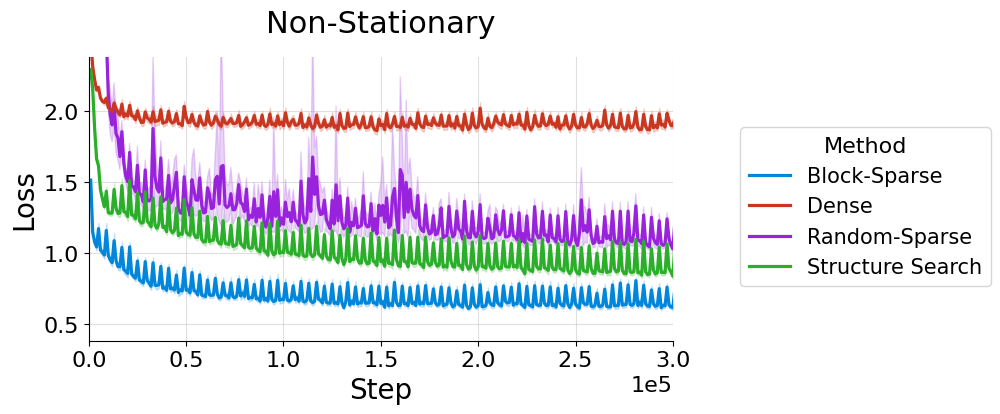

In [23]:
plot_learning_curves(
    run_df=p5_run, config_df=p5_cfg,
    n_bins=-1, figsize=(7, 4.25),
    y_col='loss_per_task', y_label='Loss',
    hue_col='Method', legend_title='Method', palette=PALETTE,
    show_ci=True,
)
plt.title('Non-Stationary')
plt.tight_layout()
plt.xlim(0, 300_000)
plt.xlabel('Step'); save_fig('p5_nonstationary_all_methods_matched_loss')
plt.show()

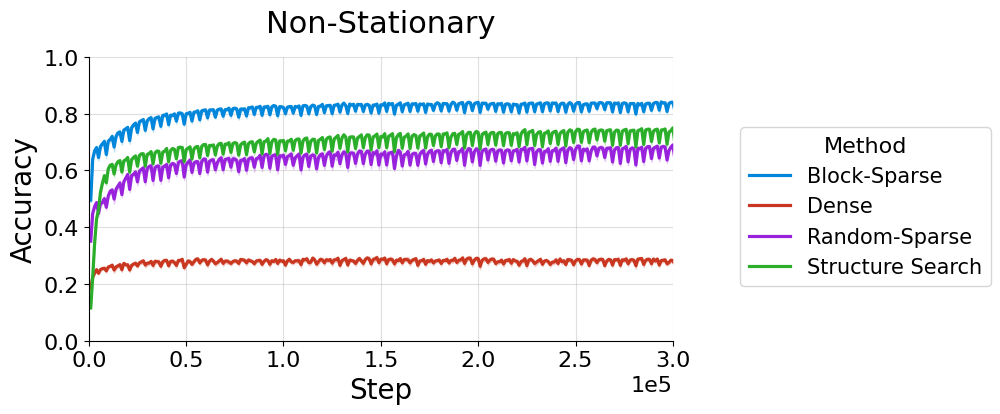

In [24]:
plot_learning_curves(
    run_df=p5_run, config_df=p5_cfg,
    n_bins=-1, figsize=(7, 4.25),
    y_col='accuracy', y_label='Accuracy', ylim=(0.0, 1.0),
    hue_col='Method', legend_title='Method', palette=PALETTE,
    show_ci=True,
)
plt.title('Non-Stationary')
plt.tight_layout()
plt.xlim(0, 300_000)
plt.xlabel('Step'); save_fig('p5_nonstationary_all_methods_matched_acc')
plt.show()

---
## 6. Non-Stationary: All 4 Methods vs N Tasks

For each (method, `n_tasks`) cell, pick the LR that maximizes asymptotic accuracy (5 seeds, no CI).
`permute_period = 3200 // n_tasks`.

In [25]:
apply_style(2)

# 03 main n_tasks sweeps live in scaling-sweep; parents only (5 seeds bundled in history).
s03_cfg, s03_run = gather(
    sweep_cfg, sweep_run,
    sweep_pattern=lambda k: k.startswith('03_') and k.endswith('_n_tasks_lr'),
    per_seed=False,
)
_p6_asym_loss = asymptotic_per_run(s03_run, 'loss_per_task').reset_index()
_p6_check = s03_cfg.merge(_p6_asym_loss, on='run_id', how='left')
print('Plot 6 method counts (total (NaN)):')
for m, grp in _p6_check.groupby('Method'):
    print(f'  {m:<18}{len(grp):>4}  ({grp["_metric"].isna().sum()} nan)')

Plot 6 method counts (total (NaN)):
  Block-Sparse        20  (5 nan)
  Dense               35  (9 nan)
  Random-Sparse       15  (0 nan)
  Structure Search    10  (0 nan)


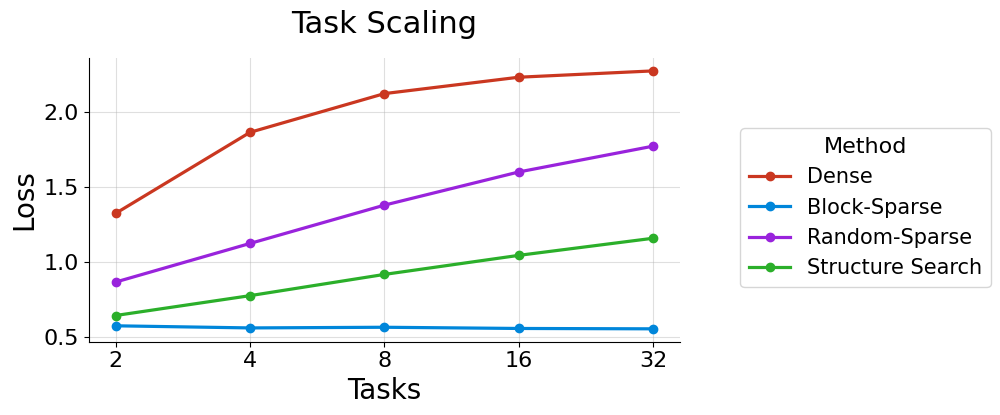

In [26]:
def asymptotic_curve(cfg, run, group_axis, metric_col, direction):
    """Best-LR asymptotic per (Method, group_axis) cell. Returns a tidy DataFrame."""
    best_cfg_, best_run_ = filter_to_best(
        cfg, run,
        group_cols=['Method', group_axis],
        metric_col=metric_col, direction=direction,
    )
    per_run = asymptotic_per_run(best_run_, metric_col).reset_index()
    df = best_cfg_.merge(per_run, on='run_id')
    return df.groupby(['Method', group_axis], dropna=False)['_metric'].mean().reset_index()


def sensitivity_plot(curve_df, x_col, x_label, y_label, title, savename,
                     x_log2=True, x_ticks=None, x_tick_labels=None, rotate=0, ylim=None):
    fig, ax = plt.subplots(figsize=plt.rcParams['figure.figsize'])
    for method in METHOD_ORDER:
        sub = curve_df[curve_df['Method'] == method].sort_values(x_col)
        if sub.empty:
            continue
        ax.plot(sub[x_col], sub['_metric'], marker='o',
                color=PALETTE[method], label=method)
    if x_log2:
        ax.set_xscale('log', base=2)
    if x_ticks is not None:
        ax.set_xticks(x_ticks)
        if x_tick_labels is not None:
            ax.set_xticklabels(x_tick_labels, rotation=rotate, ha='right' if rotate else 'center')
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(True, alpha=0.4)
    # Match plot_learning_curves' fig.legend placement so bbox_inches='tight'
    # crops to the same outer width.
    ax.get_legend().remove() if ax.get_legend() else None
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, title='Method', frameon=True,
               bbox_to_anchor=(1.05, 0.5), loc='center left')
    plt.tight_layout()
    save_fig(savename)
    plt.show()


p6_loss = asymptotic_curve(s03_cfg, s03_run, 'task.n_tasks', 'loss_per_task', direction='min')
sensitivity_plot(p6_loss, 'task.n_tasks',
                 x_label='Tasks', y_label='Loss',
                 title='Task Scaling',
                 savename='p6_nonstationary_n_tasks_loss',
                 x_ticks=[2, 4, 8, 16, 32], x_tick_labels=['2', '4', '8', '16', '32'])

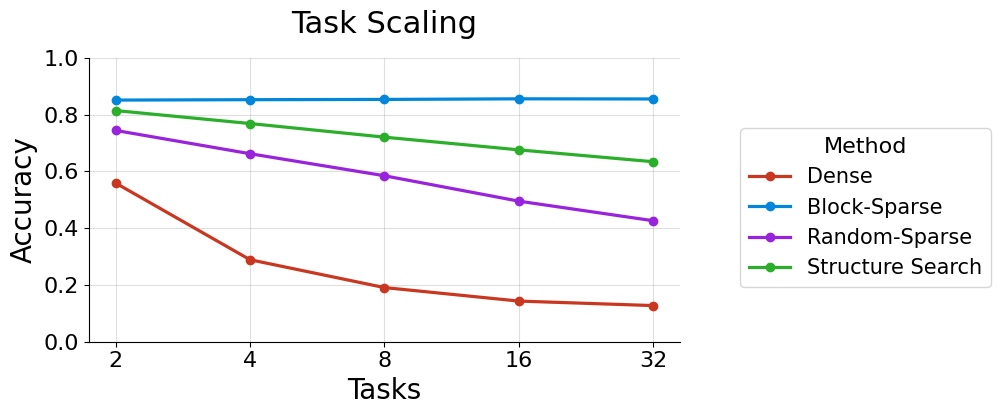

In [27]:
apply_style(2)
p6_acc = asymptotic_curve(s03_cfg, s03_run, 'task.n_tasks', 'accuracy', direction='max')
sensitivity_plot(p6_acc, 'task.n_tasks',
                 x_label='Tasks', y_label='Accuracy',
                 title='Task Scaling',
                 savename='p6_nonstationary_n_tasks_acc',
                 x_ticks=[2, 4, 8, 16, 32], x_tick_labels=['2', '4', '8', '16', '32'],
                 ylim=(0.0, 1.0))

---
## 7. Non-Stationary: All 4 Methods vs Permutation Frequency

`task.n_tasks = 4` fixed; `permute_period ∈ {200, 400, 800, 1600, 3200, 6400}`. X-axis is
frequency (1 / permute_period). Best LR per (method, period). 5 seeds.

In [28]:
apply_style(2)

s04_cfg, s04_run = gather(
    sweep_cfg, sweep_run,
    sweep_pattern=lambda k: k.startswith('04_') and k.endswith('_permute_period_lr'),
    per_seed=False,
)
s04_cfg['permute_frequency'] = 1.0 / s04_cfg['task.permute_period']
_p7_asym_loss = asymptotic_per_run(s04_run, 'loss_per_task').reset_index()
_p7_check = s04_cfg.merge(_p7_asym_loss, on='run_id', how='left')
print('Plot 7 method counts (total (NaN)):')
for m, grp in _p7_check.groupby('Method'):
    print(f'  {m:<18}{len(grp):>4}  ({grp["_metric"].isna().sum()} nan)')

Plot 7 method counts (total (NaN)):
  Block-Sparse        24  (6 nan)
  Dense               42  (6 nan)
  Random-Sparse       12  (0 nan)
  Structure Search    12  (0 nan)


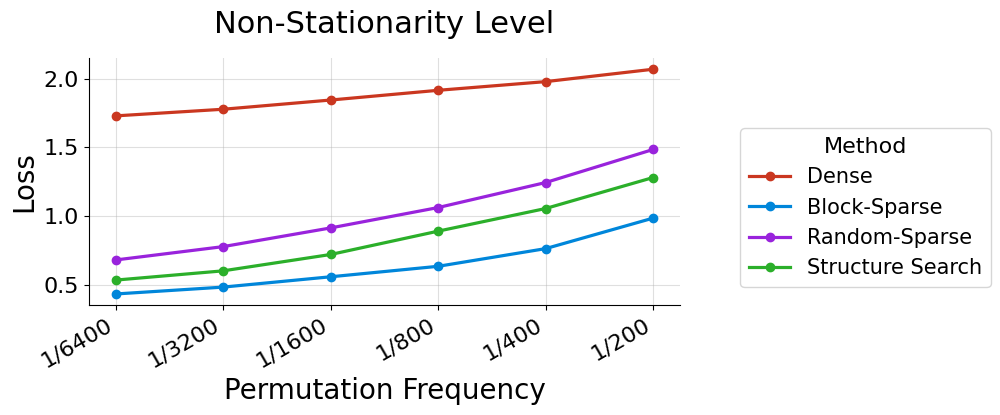

In [29]:
apply_style(2)


def asymptotic_curve_with_axis(cfg, run, group_axis, metric_col, direction, extra_axis=None):
    """Like asymptotic_curve, but keep an extra column (e.g. permute_frequency) for plotting."""
    best_cfg_, best_run_ = filter_to_best(
        cfg, run,
        group_cols=['Method', group_axis],
        metric_col=metric_col, direction=direction,
    )
    per_run = asymptotic_per_run(best_run_, metric_col).reset_index()
    df = best_cfg_.merge(per_run, on='run_id')
    agg_cols = ['Method', group_axis] + ([extra_axis] if extra_axis else [])
    return df.groupby(agg_cols, dropna=False)['_metric'].mean().reset_index()


p7_loss = asymptotic_curve_with_axis(
    s04_cfg, s04_run, 'task.permute_period', 'loss_per_task',
    direction='min', extra_axis='permute_frequency',
)
freqs = sorted(s04_cfg['permute_frequency'].dropna().unique())
freq_labels = [f'1/{int(round(1.0/f))}' for f in freqs]
sensitivity_plot(p7_loss, 'permute_frequency',
                 x_label='Permutation Frequency', y_label='Loss',
                 title='Non-Stationarity Level',
                 savename='p7_nonstationary_freq_loss',
                 x_ticks=freqs, x_tick_labels=freq_labels, rotate=30)

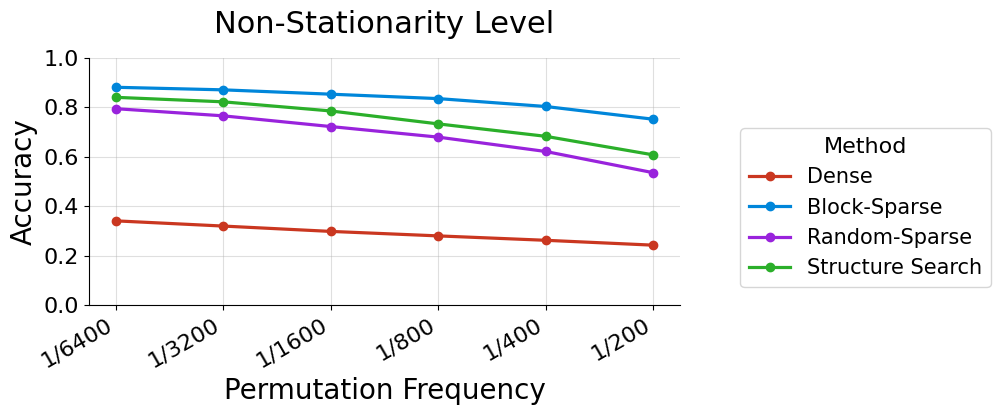

In [30]:
apply_style(2)
p7_acc = asymptotic_curve_with_axis(
    s04_cfg, s04_run, 'task.permute_period', 'accuracy',
    direction='max', extra_axis='permute_frequency',
)
sensitivity_plot(p7_acc, 'permute_frequency',
                 x_label='Permutation Frequency', y_label='Accuracy',
                 title='Non-Stationarity Level',
                 savename='p7_nonstationary_freq_acc',
                 x_ticks=freqs, x_tick_labels=freq_labels, rotate=30,
                 ylim=(0.0, 1.0))

---
## 8. Non-Stationary: Best Learning Curves at N=32

From the 03 n_tasks sweeps at `n_tasks = 32`, take the best LR per method and plot the
seed-averaged learning curve (5 seeds, no CI).

In [31]:
apply_style(2)

p8_cfg = s03_cfg[s03_cfg['task.n_tasks'] == 32].copy()
p8_run = s03_run[s03_run['run_id'].isin(p8_cfg['run_id'])].copy()
p8_cfg_best, p8_run_best = filter_to_best(
    p8_cfg, p8_run,
    group_cols=['Method'], metric_col='accuracy', direction='max',
)
print('Plot 8 selected runs:')
print(p8_cfg_best.groupby(['Method', 'optimizer.learning_rate']).size())

Plot 8 selected runs:
Method            optimizer.learning_rate
Block-Sparse      0.003906                   1
Dense             0.000244                   1
Random-Sparse     0.015625                   1
Structure Search  0.015625                   1
dtype: int64


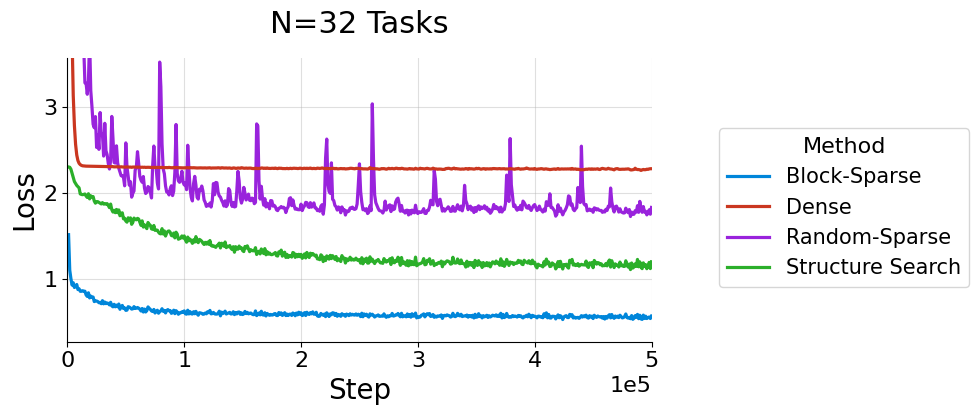

In [32]:
plot_learning_curves(
    run_df=p8_run_best, config_df=p8_cfg_best,
    n_bins=-1, figsize=(7, 4.25),
    y_col='loss_per_task', y_label='Loss',
    hue_col='Method', legend_title='Method', palette=PALETTE,
    show_ci=False,
)
plt.title('N=32 Tasks')
plt.tight_layout()
plt.xlabel('Step'); save_fig('p8_nonstationary_n32_loss')
plt.show()

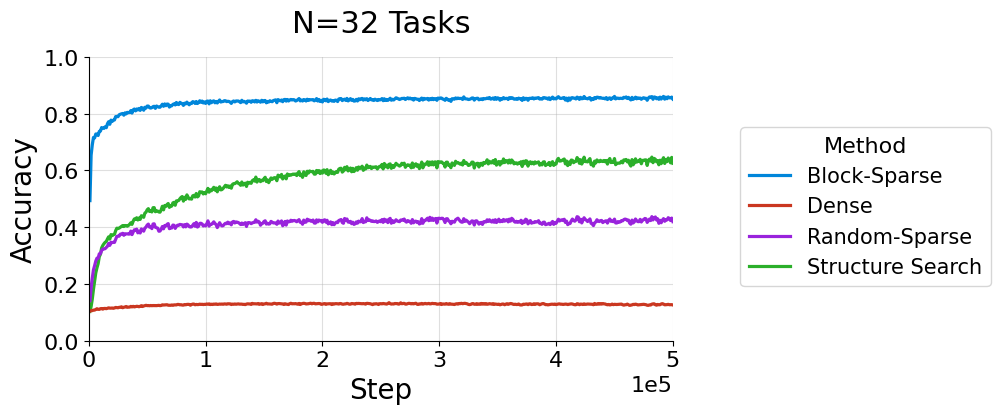

In [33]:
plot_learning_curves(
    run_df=p8_run_best, config_df=p8_cfg_best,
    n_bins=-1, figsize=(7, 4.25),
    y_col='accuracy', y_label='Accuracy', ylim=(0.0, 1.0),
    hue_col='Method', legend_title='Method', palette=PALETTE,
    show_ci=False,
)
plt.title('N=32 Tasks')
plt.tight_layout()
plt.xlabel('Step'); save_fig('p8_nonstationary_n32_acc')
plt.show()

---
## 9. Non-Stationary: Best Learning Curves at Highest Frequency

From the 04 sweeps at `permute_period = 200` (the highest non-stationarity), take the best LR
per method (5 seeds, no CI).

In [34]:
apply_style(2)

p9_cfg = s04_cfg[s04_cfg['task.permute_period'] == 200].copy()
p9_run = s04_run[s04_run['run_id'].isin(p9_cfg['run_id'])].copy()
p9_cfg_best, p9_run_best = filter_to_best(
    p9_cfg, p9_run,
    group_cols=['Method'], metric_col='accuracy', direction='max',
)
print('Plot 9 selected runs:')
print(p9_cfg_best.groupby(['Method', 'optimizer.learning_rate']).size())

Plot 9 selected runs:
Method            optimizer.learning_rate
Block-Sparse      0.007812                   1
Dense             0.001953                   1
Random-Sparse     0.007812                   1
Structure Search  0.015625                   1
dtype: int64


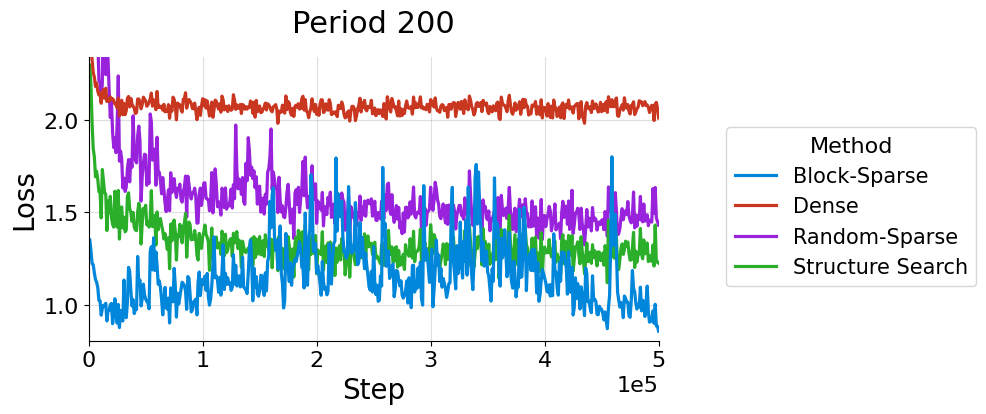

In [35]:
plot_learning_curves(
    run_df=p9_run_best, config_df=p9_cfg_best,
    n_bins=-1, figsize=(7, 4.25),
    y_col='loss_per_task', y_label='Loss',
    hue_col='Method', legend_title='Method', palette=PALETTE,
    show_ci=False,
)
plt.title('Period 200')
plt.tight_layout()
plt.xlabel('Step'); save_fig('p9_nonstationary_period200_loss')
plt.show()

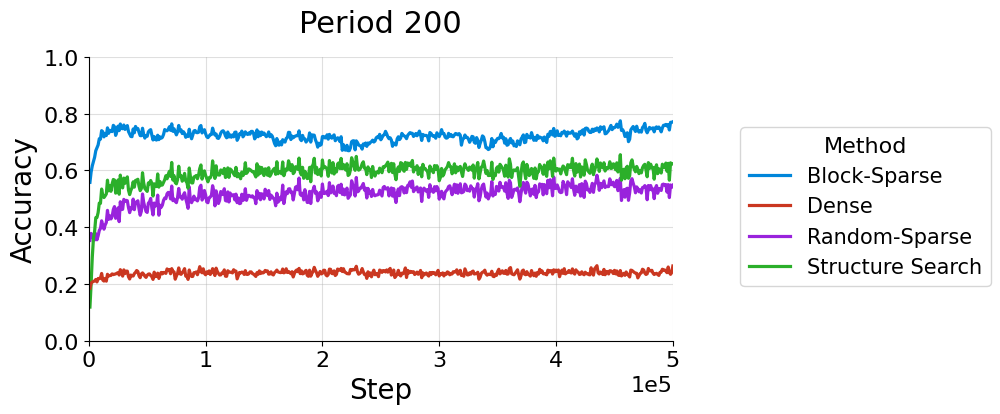

In [36]:
plot_learning_curves(
    run_df=p9_run_best, config_df=p9_cfg_best,
    n_bins=-1, figsize=(7, 4.25),
    y_col='accuracy', y_label='Accuracy', ylim=(0.0, 1.0),
    hue_col='Method', legend_title='Method', palette=PALETTE,
    show_ci=False,
)
plt.title('Period 200')
plt.tight_layout()
plt.xlabel('Step'); save_fig('p9_nonstationary_period200_acc')
plt.show()